Training CSV: 857 samples
dog    644
cat    213
[Full train CSV] Unique class values in masks: [0, 1, 2]
  OK — all 3 classes present (0=bg, 1=cat, 2=dog)
Seed 22: train=771  val=86  (from Cat_black_grey_Dog_brown_white_train.csv)

Training seed 22 on cuda:2
Loading TransUNet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz
load_pretrained: grid-size from 14 to 16
Epoch 1/100:
  Train Loss:0.5442  Dice:0.7643  Acc:0.8375  IoU:0.6508
  Val   Loss:0.5414  Dice:0.8871  Acc:0.9321  IoU:0.8019
Epoch 10/100:
  Train Loss:0.1260  Dice:0.9536  Acc:0.9636  IoU:0.9123
  Val   Loss:0.1119  Dice:0.9620  Acc:0.9712  IoU:0.9269
Epoch 20/100:
  Train Loss:0.0780  Dice:0.9351  Acc:0.9502  IoU:0.8818
  Val   Loss:0.1217  Dice:0.8740  Acc:0.9323  IoU:0.7812
Epoch 30/100:
  Train Loss:0.0530  Dice:0.9515  Acc:0.9594  IoU:0.9093
  Val   Loss:0.0419  Dice:0.9660  Acc:0.9721  IoU:0.9342
Epoch 40/100:
  Train Loss:0.041

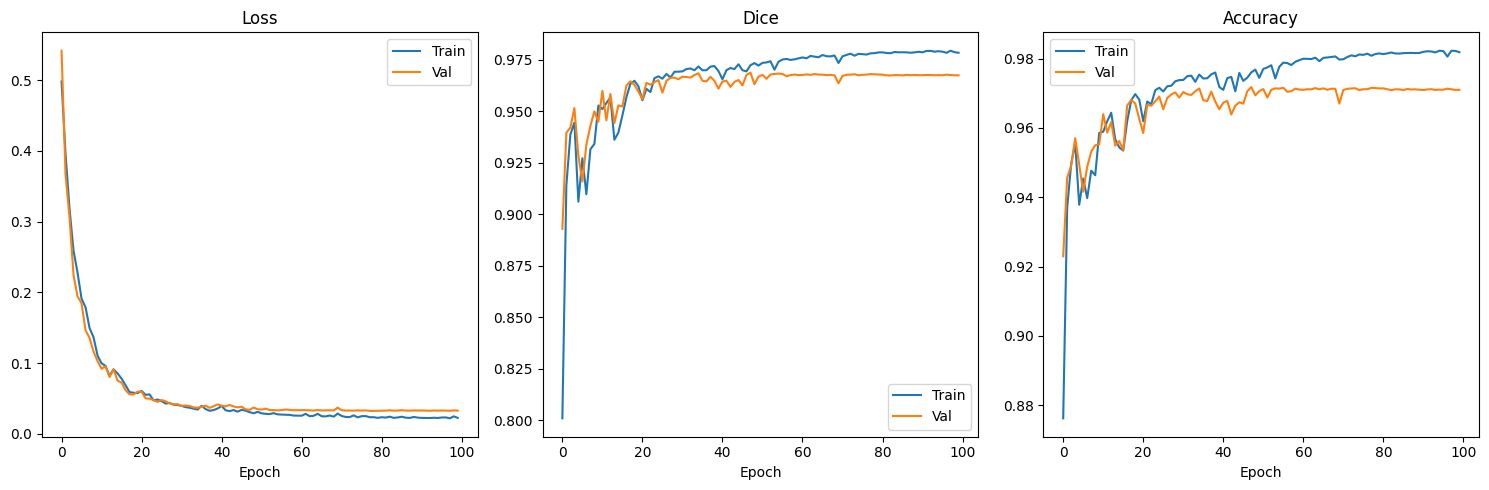

Sample 1: GT species=cat, Pred species=cat
Sample 2: GT species=cat, Pred species=cat
Sample 3: GT species=cat, Pred species=cat
Sample 4: GT species=dog, Pred species=dog
Sample 5: GT species=dog, Pred species=dog
Avg Test Dice: 0.1934


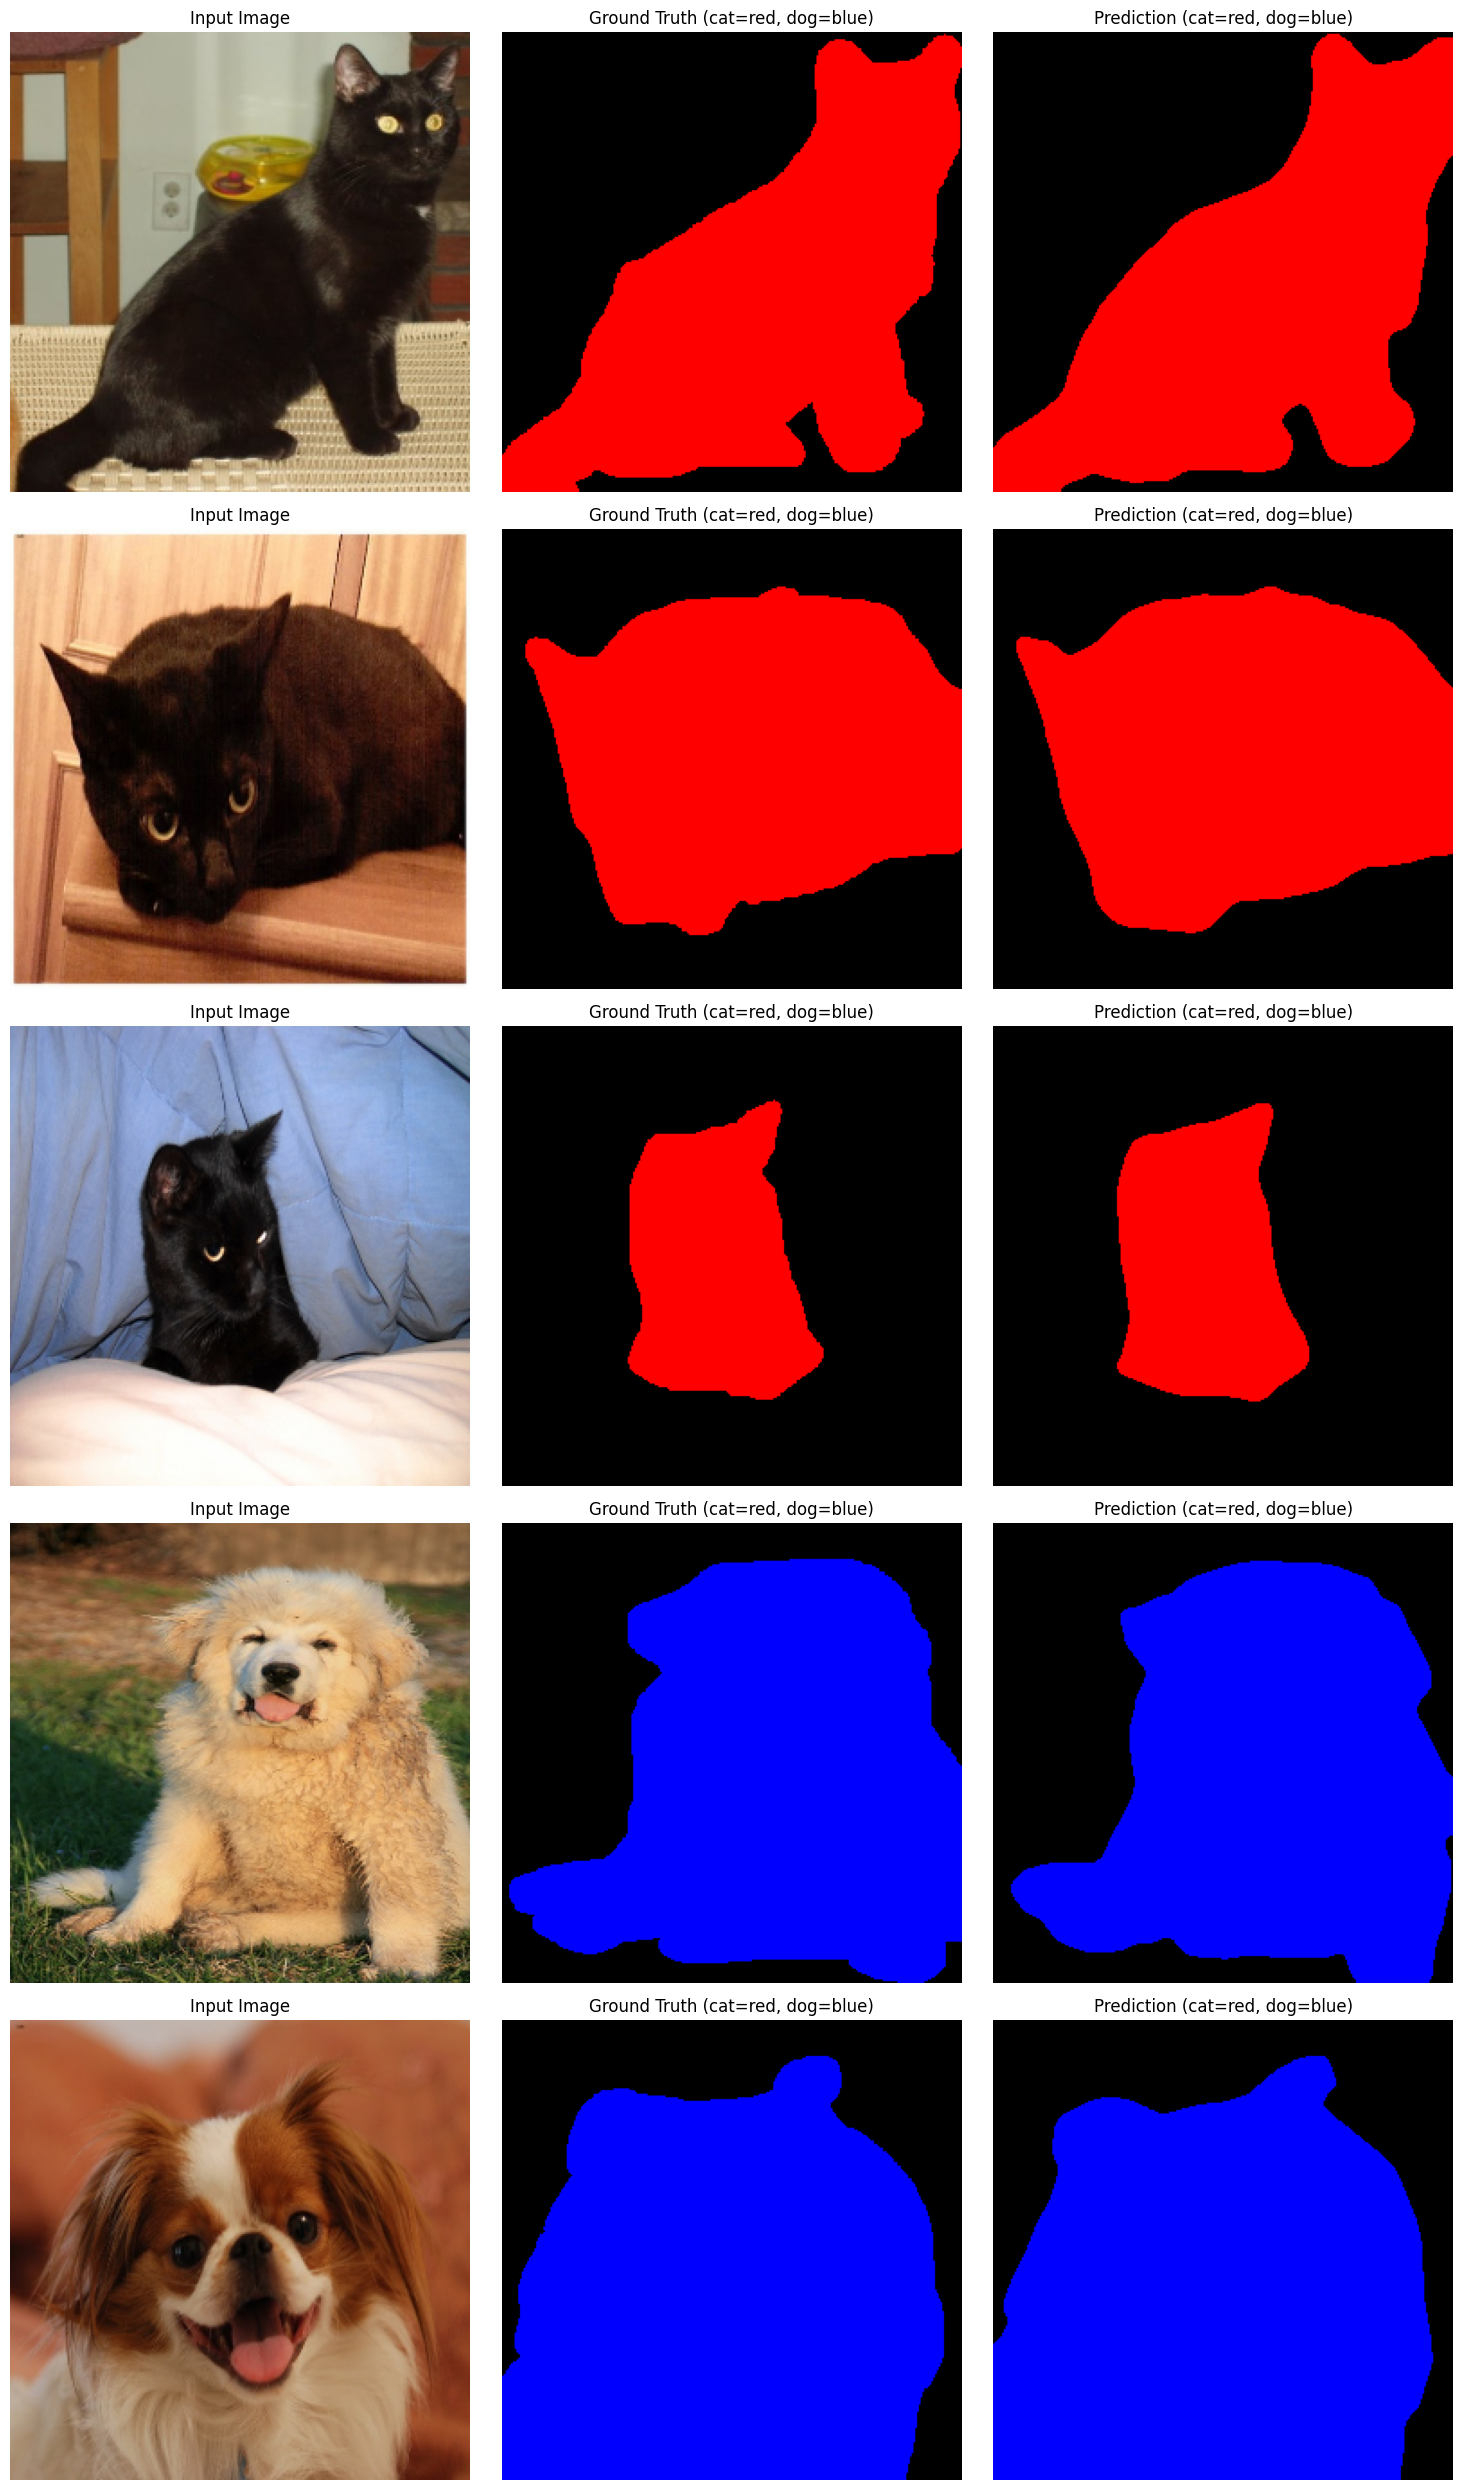


Multi-seed training complete:
  seed 22: dice=0.9512  iou=0.9076  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/pets_checkpoints/multiseed/TransUNet_Pets_multiclass_seed22_epoch100.pth
  seed 42: dice=0.9438  iou=0.8941  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/pets_checkpoints/multiseed/TransUNet_Pets_multiclass_seed42_epoch100.pth
  seed 123: dice=0.9675  iou=0.9370  → /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet/pets_checkpoints/multiseed/TransUNet_Pets_multiclass_seed123_epoch100.pth

IID test evaluation (Cat_black_grey_Dog_brown_white_test_IID.csv)
  Cat/Black        (n=  38): dice=0.9683  iou=0.9386
  Cat/Gray         (n=  16): dice=0.9460  iou=0.8984
  Dog/Brown        (n= 142): dice=0.9566  iou=0.9172
  Dog/White        (n=  24): dice=0.9632  iou=0.9290


In [ ]:
import os
import sys
from pathlib import Path

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import albumentations as A
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp  # DiceLoss only
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
import random

# TransUNet (https://github.com/Beckschen/TransUNet)
TRANSUNET_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/TransUNet"
if TRANSUNET_DIR not in sys.path:
    sys.path.insert(0, TRANSUNET_DIR)
from transunet_model import build_transunet, DEFAULT_PRETRAINED

# Paths & hyperparameters (match run_multiseed_training.py)
ROOT = Path("/home/ahsan/test-project/ISIC-2019/Pet_data")
PET_DATA_ROOT = ROOT / "pet_fixed_by_label"
PET_CSV_PATH = (
    PET_DATA_ROOT
    / "Metadata/Metadata_final/Cat_black_grey_Dog_brown_white_train.csv"
)
TEST_CSV_PATH = (
    PET_DATA_ROOT
    / "Metadata/Metadata_final/Cat_black_grey_Dog_brown_white_test_IID.csv"
)

BATCH_SIZE = 32
NUM_CLASSES = 3
SPECIES_TO_CLASS = {"cat": 1, "dog": 2}
CLASS_NAMES = ["background", "cat", "dog"]
EPOCHS = 100
LR_INITIAL = 1e-4
VAL_SPLIT = 0.1
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256
SEEDS = [22, 42, 123]
VIT_NAME = "R50-ViT-B_16"
N_SKIP = 3
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
CHECKPOINT_DIR = TRANSUNET_DIR + "/pets_checkpoints/multiseed"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Transforms 
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Dataset — binary pet mask + species (cat/dog) → 3-class mask
class PetDataset(Dataset):
    def __init__(self, csv_path, data_root, transform=None, indices=None):
        self.data_root = Path(data_root)
        self.transform = transform
        df = pd.read_csv(csv_path)
        if indices is not None:
            df = df.iloc[list(indices)].reset_index(drop=True)
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_root / row["image"]
        mask_path = self.data_root / row["mask"]

        image = np.array(Image.open(img_path).convert("RGB"))
        binary_mask = np.array(Image.open(mask_path).convert("L")) > 127
        species_class = SPECIES_TO_CLASS[str(row["species"]).lower()]
        mask = np.zeros(binary_mask.shape, dtype=np.int64)
        mask[binary_mask] = species_class

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        if mask.is_floating_point():
            mask = mask.round()
        return image, mask.long()


class PetSubgroupDataset(Dataset):
    """IID test rows (optionally filtered by species/color subgroup)."""
    def __init__(self, sub_df, data_root, transform=None):
        self.df = sub_df.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.data_root / row["image"]
        mask_path = self.data_root / row["mask"]
        species = str(row["species"]).lower().strip()

        image = np.array(Image.open(img_path).convert("RGB"))
        binary_mask = np.array(Image.open(mask_path).convert("L")) > 127
        species_cls = SPECIES_TO_CLASS[species]
        mask = np.zeros(binary_mask.shape, dtype=np.int64)
        mask[binary_mask] = species_cls

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"]

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        if mask.is_floating_point():
            mask = mask.round()
        return image, mask.long()


def build_loaders(seed):
    pet_df = pd.read_csv(PET_CSV_PATH)
    train_indices, val_indices = train_test_split(
        pet_df.index,
        test_size=VAL_SPLIT,
        random_state=seed,
        stratify=pet_df["species"],
    )
    train_dataset = PetDataset(
        PET_CSV_PATH, PET_DATA_ROOT, transform=train_transform, indices=train_indices
    )
    val_dataset = PetDataset(
        PET_CSV_PATH, PET_DATA_ROOT, transform=val_transform, indices=val_indices
    )
    print(
        f"Seed {seed}: train={len(train_dataset)}  val={len(val_dataset)}  "
        f"(from {PET_CSV_PATH.name})"
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )
    return train_loader, val_loader


def verify_dataset_classes(dataset, name="Dataset", n_batches=10):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    all_classes = set()
    for i, (_, masks) in enumerate(loader):
        for v in masks.unique().tolist():
            all_classes.add(int(v))
        if i >= n_batches:
            break
    print(f"[{name}] Unique class values in masks: {sorted(all_classes)}")
    if 2 not in all_classes:
        print("  *** WARNING: class 2 (dog) NOT found — check species column in CSV ***")
    else:
        print("  OK — all 3 classes present (0=bg, 1=cat, 2=dog)")


# Quick sanity check on full training CSV (split is per-seed inside training loop)
_pet_df = pd.read_csv(PET_CSV_PATH)
print(f"Training CSV: {len(_pet_df)} samples")
print(_pet_df["species"].value_counts().to_string())
_verify_ds = PetDataset(PET_CSV_PATH, PET_DATA_ROOT, transform=train_transform)
verify_dataset_classes(_verify_ds, name="Full train CSV")

criterion = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

# Metrics
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    preds        = outputs.argmax(dim=1)
    acc          = (preds == masks).float().mean().item()
    preds_flat   = preds.view(-1)
    masks_flat   = masks.view(-1)
    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()
    inter         = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds   = preds_one_hot.sum(dim=0)
    total_masks   = masks_one_hot.sum(dim=0)
    union         = total_preds + total_masks - inter

    # Skip background (index 0)
    inter       = inter[1:]
    union       = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)
    if class_present.sum() == 0:
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class  = (inter + smooth) / (union + smooth)

    return {
        "acc"  : acc,
        "dice" : dice_per_class[class_present].mean().item(),
        "iou"  : iou_per_class[class_present].mean().item(),
    }

# Training Loop (one run per seed; train/val split is seed-dependent)
all_seed_runs = []

for seed in SEEDS:
    set_seed(seed)
    train_loader, val_loader = build_loaders(seed)
    print(f"\n{'='*70}\nTraining seed {seed} on {DEVICE}\n{'='*70}")

    model = build_transunet(
        num_classes     = NUM_CLASSES,
        img_size        = IMG_SIZE,
        vit_name        = VIT_NAME,
        n_skip          = N_SKIP,
        pretrained_path = PRETRAINED_PATH,
        device          = DEVICE,
    )
    optimizer = optim.Adam(model.parameters(), lr=LR_INITIAL)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      patience=5, factor=0.5)

    train_losses, val_losses         = [], []
    train_dices,  val_dices          = [], []
    train_accuracies, val_accuracies = [], []
    training_iou, validating_iou     = [], []

    for epoch in range(EPOCHS):
        model.train()
        train_loss = train_dice = train_acc = train_iou = 0.0

        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            train_acc  += m["acc"]
            train_dice += m["dice"]
            train_iou  += m["iou"]

        n = len(train_loader)
        avg_train_loss = train_loss / n
        avg_train_dice = train_dice / n
        avg_train_acc  = train_acc  / n
        avg_train_iou  = train_iou  / n

        model.eval()
        val_loss = val_dice = val_acc = val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, masks)

                val_loss += loss.item()
                m = compute_metrics(outputs, masks, NUM_CLASSES)
                val_acc  += m["acc"]
                val_dice += m["dice"]
                val_iou  += m["iou"]

        n = len(val_loader)
        avg_val_loss = val_loss / n
        avg_val_dice = val_dice / n
        avg_val_acc  = val_acc  / n
        avg_val_iou  = val_iou  / n

        train_losses.append(avg_train_loss); val_losses.append(avg_val_loss)
        train_dices.append(avg_train_dice);  val_dices.append(avg_val_dice)
        train_accuracies.append(avg_train_acc); val_accuracies.append(avg_val_acc)
        training_iou.append(avg_train_iou);  validating_iou.append(avg_val_iou)

        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}:")
            print(f"  Train Loss:{avg_train_loss:.4f}  Dice:{avg_train_dice:.4f}  "
                  f"Acc:{avg_train_acc:.4f}  IoU:{avg_train_iou:.4f}")
            print(f"  Val   Loss:{avg_val_loss:.4f}  Dice:{avg_val_dice:.4f}  "
                  f"Acc:{avg_val_acc:.4f}  IoU:{avg_val_iou:.4f}")

    ckpt_path = f"{CHECKPOINT_DIR}/TransUNet_Pets_multiclass_seed{seed}_epoch{EPOCHS}.pth"
    torch.save(model.state_dict(), ckpt_path)
    print(f"Saved checkpoint → {ckpt_path}")
    all_seed_runs.append({
        "seed": seed,
        "checkpoint": ckpt_path,
        "final_val_dice": val_dices[-1],
        "final_val_iou": validating_iou[-1],
    })

# Plot last seed's curves
seed = all_seed_runs[-1]["seed"]
print(f"\nPlotting curves for last seed ({seed})")
# Plotting 
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,2)
plt.plot(train_dices, label='Train'); plt.plot(val_dices, label='Val')
plt.title('Dice'); plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,3)
plt.plot(train_accuracies, label='Train'); plt.plot(val_accuracies, label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# Visualization
def mask_to_rgb(mask_2d):
    if isinstance(mask_2d, torch.Tensor):
        mask_2d = mask_2d.cpu().numpy()
    mask_2d = np.squeeze(mask_2d)
    h, w = mask_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    rgb[mask_2d == 0] = [0, 0, 0]       # background → black
    rgb[mask_2d == 1] = [255, 0, 0]     # cat        → red
    rgb[mask_2d == 2] = [0, 0, 255]     # dog        → blue
    return rgb

model.eval()
num_examples  = 5
val_iter      = iter(val_loader)
fig, axes     = plt.subplots(num_examples, 3, figsize=(15, 5 * num_examples))
example_count = 0
test_dice     = 0.0

with torch.no_grad():
    while example_count < num_examples:
        images, masks = next(val_iter)
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        outputs       = model(images)
        pred_labels   = outputs.argmax(dim=1)

        m = compute_metrics(outputs, masks, NUM_CLASSES)
        test_dice += m["dice"]

        for i in range(images.size(0)):
            mask_np = masks[i].cpu().numpy()
            if mask_np.max() > 0:
                img      = np.transpose(images[i].cpu().numpy(), (1, 2, 0))
                mean     = np.array([0.485, 0.456, 0.406])
                std      = np.array([0.229, 0.224, 0.225])
                img      = (img * std + mean).clip(0, 1)
                pred_np  = pred_labels[i].cpu().numpy()

                species_gt = CLASS_NAMES[int(mask_np.max())]
                species_pred = CLASS_NAMES[int(pred_np.max())] if pred_np.max() > 0 else "background"
                print(f"Sample {example_count+1}: GT species={species_gt}, Pred species={species_pred}")

                axes[example_count, 0].imshow(img)
                axes[example_count, 0].set_title("Input Image")
                axes[example_count, 0].axis("off")

                axes[example_count, 1].imshow(mask_to_rgb(mask_np))
                axes[example_count, 1].set_title("Ground Truth (cat=red, dog=blue)")
                axes[example_count, 1].axis("off")

                axes[example_count, 2].imshow(mask_to_rgb(pred_np))
                axes[example_count, 2].set_title("Prediction (cat=red, dog=blue)")
                axes[example_count, 2].axis("off")

                example_count += 1
                if example_count >= num_examples:
                    break

print(f"Avg Test Dice: {test_dice / num_examples:.4f}")
plt.tight_layout()
plt.show()

print("\nMulti-seed training complete:")
for run in all_seed_runs:
    print(f"  seed {run['seed']}: dice={run['final_val_dice']:.4f}  iou={run['final_val_iou']:.4f}  → {run['checkpoint']}")

# ── IID test evaluation (last seed's model, same protocol as run_multiseed_training.py) ──
df_test = pd.read_csv(TEST_CSV_PATH)
df_test.columns = df_test.columns.str.strip()
df_test["species"] = df_test["species"].str.lower().str.strip()
df_test["color"] = df_test["color"].str.lower().str.strip()

subgroups = [
    {"species": sp, "color": col}
    for (sp, col) in df_test.groupby(["species", "color"]).groups.keys()
]

print(f"\n{'='*70}\nIID test evaluation ({TEST_CSV_PATH.name})\n{'='*70}")
model.eval()
for sg in subgroups:
    species, color = sg["species"], sg["color"]
    label = f"{species.capitalize()}/{color.capitalize()}"
    sub_df = df_test[(df_test["species"] == species) & (df_test["color"] == color)]
    loader = DataLoader(
        PetSubgroupDataset(sub_df, PET_DATA_ROOT, transform=val_transform),
        batch_size=8,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )
    tot_dice = tot_iou = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            tot_dice += m["dice"]
            tot_iou += m["iou"]
    n = len(loader)
    print(f"  {label:16s} (n={len(sub_df):4d}): dice={tot_dice/n:.4f}  iou={tot_iou/n:.4f}")